# Задание 1

In [53]:
from scipy.stats import chi2, norm
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import lilliefors

# Функция для вычисления критерия согласия Пирсона хи-квадрат
def chi_square_test(X):
    observed_values = X.value_counts().sort_index().values
    expected_values = np.random.normal(X.mean(), X.std(), len(observed_values))

    # Расчет статистики хи-квадрат
    chi_square_stat = np.sum((observed_values - expected_values)**2 / expected_values)

    # Расчет степеней свободы
    degrees_of_freedom = len(observed_values) - 1

    return chi_square_stat, degrees_of_freedom

# H0 - рейтинг футболистов имеет нормальное распределение
# H1 - распределение не является нормальным

df = pd.read_csv('fifa_players_stats.csv')
X = df['Overall']

# Определение уровня значимости (alpha)
alpha = 0.05

# Проверка с помощью критерия согласия Пирсона хи-квадрат
chi_square_stat, degrees_of_freedom = chi_square_test(X)
print("Статистика хи-квадрат:", chi_square_stat)
print("Степени свободы:", degrees_of_freedom)

# Нахождение критического значения хи-квадрат
critical_value = chi2.ppf(1-alpha, degrees_of_freedom)

# Вывод результатов
if chi_square_stat > critical_value:
    print("Критерий согласия Пирсона хи-квадрат: H0 отвергается, рейтинг футболистов не распределен нормально.")
else:
    print("Критерий согласия Пирсона хи-квадрат: H0 не отвергается, рейтинг футболистов распределен нормально.")

# Аналогичное исследование, но с помощью критерия Лиллифорса (частный случай критерия Колмогорова-Смирнова)
lilliefors_test = lilliefors(X)

# Вывод результатов
if lilliefors_test[1] < alpha:
    print("Критерий Лиллифорса: H0 отвергается, рейтинг футболистов не распределен нормально.")
else:
    print("Критерий Лиллифорса: H0 не отвергается, рейтинг футболистов распределен нормально.")

# Построение гистограммы распределения значений X
# plt.figure(figsize=(10, 6))
# plt.hist(X, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
# plt.title('Распределение значений переменной X')
# plt.xlabel('Значения X')
# plt.ylabel('Частота')
# plt.grid(axis='y', alpha=0.75)
# plt.show()

Статистика хи-квадрат: 194191.07504113406
Степени свободы: 44
Критерий согласия Пирсона хи-квадрат: H0 отвергается, рейтинг футболистов не распределен нормально.
Критерий Лиллифорса: H0 отвергается, рейтинг футболистов не распределен нормально.


# Задание 2

Принимается нулевая гипотеза: рейтинг молодых и старших футболистов однороден
Отвергается нулевая гипотеза: рейтинг молодых и старших футболистов неоднороден


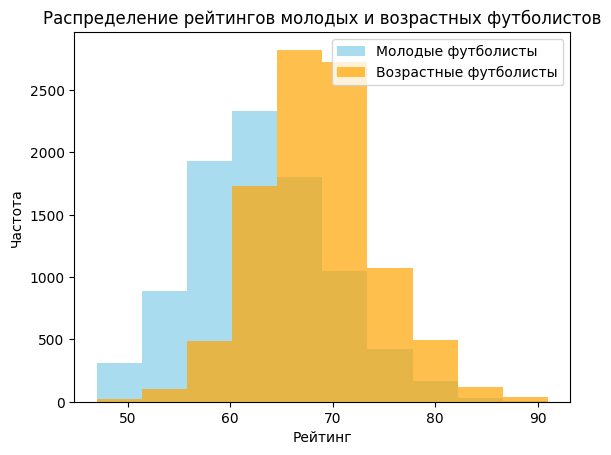

In [51]:
from scipy.stats import chi2
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt

df = pd.read_csv('fifa_players_stats.csv')
X = df[['Overall', 'Age']].dropna()

# Определение уровня значимости (alpha)
alpha = 0.05
# Выбор порога возраста
threshold_age = 25

# Разделение на молодых и старших футболистов по порогу возраста
young_players = df[df['Age'] < threshold_age]['Overall']
old_players = df[df['Age'] >= threshold_age]['Overall']

# Создание таблицы сопряженности для критерия хи-квадрат
observed = pd.crosstab(young_players, old_players)

# Вычисление ожидаемых значений
expected = np.outer(observed.sum(axis=1), observed.sum(axis=0)) / observed.sum().sum()

# Вычисление статистики критерия хи-квадрат
chi2_stat = np.sum((observed - expected)**2 / expected)
degrees_of_freedom = (observed.shape[0] - 1) * (observed.shape[1] - 1)

# Определение критического значения для уровня значимости 0.05
critical_value = chi2.ppf(1-alpha, degrees_of_freedom)

# Вывод результатов
if chi2_stat.sum() > critical_value:
    print("Отвергается нулевая гипотеза: рейтинг молодых и старших футболистов неоднороден")
else:
    print("Принимается нулевая гипотеза: рейтинг молодых и старших футболистов однороден")

# Применение критерия Колмогорова-Смирнова
ks_stat, p_value = ks_2samp(young_players, old_players)

# Вывод результатов
if p_value < alpha:
    print("Отвергается нулевая гипотеза: рейтинг молодых и старших футболистов неоднороден")
else:
    print("Принимается нулевая гипотеза: рейтинг молодых и старших футболистов однороден")

# Построение графика двух распределений
plt.hist(young_players, color='skyblue', alpha=0.7, label='Молодые футболисты')
plt.hist(old_players, color='orange', alpha=0.7, label='Возрастные футболисты')

plt.xlabel('Рейтинг')
plt.ylabel('Частота')
plt.title('Распределение рейтингов молодых и возрастных футболистов')
plt.legend()
plt.show()

# Задание 3

In [52]:
import pandas as pd
import numpy as np
from scipy.stats import chi2
from scipy.stats import spearmanr

# Загрузка данных
df = pd.read_csv('fifa_players_stats.csv')
X = df[['Overall', 'Nationality']]

# Создание таблицы сопряженности для критерия хи-квадрат
observed = pd.crosstab(X['Overall'], X['Nationality'])

# Вычисление статистики хи-квадрат
chi2_stat = 0
for i in range(observed.shape[0]):
    for j in range(observed.shape[1]):
        O = observed.iloc[i, j]
        E = np.sum(observed.iloc[i, :]) * np.sum(observed.iloc[:, j]) / np.sum(observed)
        chi2_stat += (O - E)**2 / E

# Определение критического значения для уровня значимости 0.05
degrees_of_freedom = (observed.shape[0] - 1) * (observed.shape[1] - 1)
critical_value = chi2.ppf(0.95, degrees_of_freedom)

# Вывод результатов
if chi2_stat.sum() > critical_value:
    print("Отвергается нулевая гипотеза: рейтинг футболистов зависит от их национальности")
else:
    print("Принимается нулевая гипотеза: рейтинг футболистов независим от их национальности")

# Вычисление коэффициента корреляции Спирмена
corr, p_value = spearmanr(X['Overall'], X['Nationality'])

# Вывод результатов
if p_value < alpha:
    print("Отвергается нулевая гипотеза: рейтинг футболистов зависит от их национальности (согласно коэффициенту Спирмена)")
else:
    print("Принимается нулевая гипотеза: рейтинг футболистов независим от их национальности (согласно коэффициенту Спирмена)")

Отвергается нулевая гипотеза: рейтинг футболистов зависит от их национальности
Отвергается нулевая гипотеза: рейтинг футболистов зависит от их национальности (согласно коэффициенту Спирмена)
